# 02 - Data Cleaning

Four IoT pathologies, each handled explicitly:

1. **Missing timestamps** -> reindex onto a gap-free hourly grid so gaps become explicit `NaN`s.
2. **Sensor dropouts** (`-200`) -> convert to `NaN`, then **time-aware interpolation capped at 6 h**. Longer outages stay `NaN` and are dropped later - imputing a full day we never observed would be fiction.
3. **Out-of-bounds spikes** -> **Hampel filter** (rolling median + MAD). MAD is robust to the very outliers we are removing, unlike a mean/std z-score.
4. **Noise** -> left in the raw signal and absorbed later by rolling features, rather than destroying information here.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
from IPython.display import Image, display
from src import config as C, data_cleaning as dc, plots as P
raw = dc.load_raw()
cleaned = dc.clean(raw)
rep = dc.cleaning_report(raw, cleaned)
display(rep)

,missing_%_raw,missing_%_clean
AH,3.91,3.11
C6H6(GT),3.91,3.13
CO(GT),17.99,14.25
NMHC(GT),90.23,NaN
NO2(GT),17.55,12.72
NOx(GT),17.52,12.70
PT08.S1(CO),3.91,3.11
PT08.S2(NMHC),3.91,3.12
PT08.S3(NOx),3.91,3.13
PT08.S4(NO2),3.91,3.12


### Before / after on a sample window
Red dots = raw observed readings; green line = cleaned series. Short gaps are bridged, isolated spikes are pulled back to the local level.

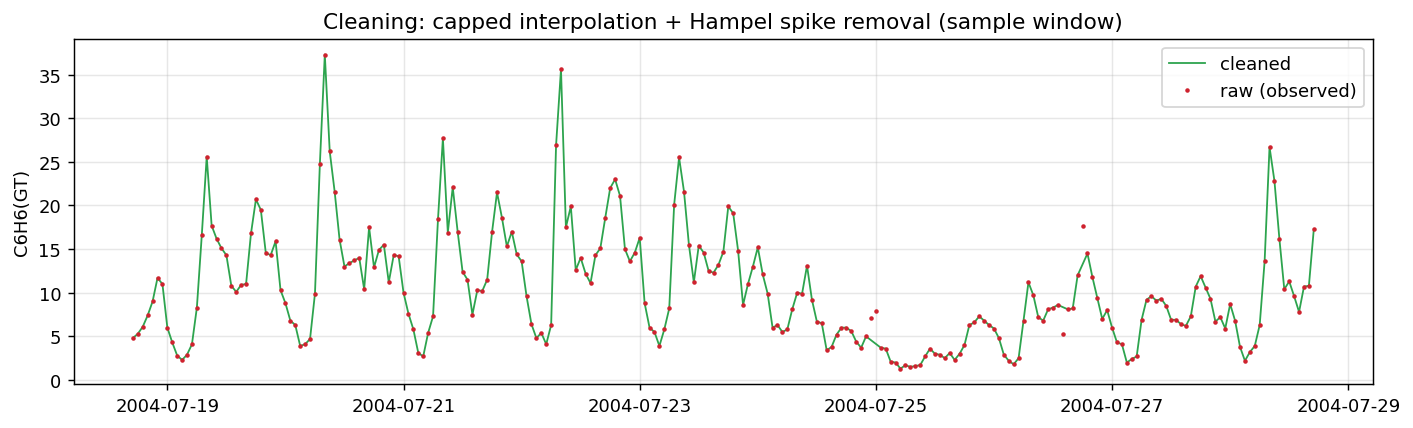

saved cleaned -> /home/claude/iot-trend-prediction/data/processed/clean.csv


In [2]:
start = cleaned.index[len(cleaned)//3]
P.plot_cleaning_window(raw, cleaned, start)
display(Image('../reports/figures/04_cleaning_window.png'))
cleaned.to_csv(C.DATA_PROCESSED)
print('saved cleaned ->', C.DATA_PROCESSED)